<a href="https://colab.research.google.com/github/Abiraminagarajan-19/AI-crop-recommendation-system/blob/main/project4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pickle
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
data=pd.read_csv(r"/content/bank1.csv")

In [ ]:
data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProduct,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
2,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
3,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
4,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1944 entries, 0 to 1943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       1944 non-null   int64  
 1   Surname          1944 non-null   object 
 2   CreditScore      1944 non-null   int64  
 3   Geography        1944 non-null   object 
 4   Gender           1944 non-null   object 
 5   Age              1944 non-null   int64  
 6   Tenure           1944 non-null   int64  
 7   Balance          1944 non-null   float64
 8   NumOfProduct     1944 non-null   int64  
 9   HasCrCard        1944 non-null   int64  
 10  IsActiveMember   1944 non-null   int64  
 11  EstimatedSalary  1944 non-null   float64
 12  Exited           1944 non-null   int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 197.6+ KB


In [ ]:
data.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProduct,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.944000e+03,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000,1944.000000
mean,1.569007e+07,648.631687,41.287037,5.007716,81474.884522,1.505144,0.708333,0.444959,99806.829064,0.514403
std,7.214821e+04,100.167616,10.557439,2.889177,61491.259144,0.676017,0.454647,0.497089,57584.617180,0.499921
min,1.556571e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.562799e+07,580.000000,34.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50417.950000,0.000000
50%,1.568913e+07,652.000000,40.000000,5.000000,102494.415000,1.000000,1.000000,0.000000,100456.215000,1.000000
75%,1.575172e+07,721.000000,48.000000,8.000000,129259.517500,2.000000,1.000000,1.000000,147796.707500,1.000000
max,1.581563e+07,850.000000,84.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199725.390000,1.000000


In [ ]:
print("First 5 Rows")
print(data.head())
print("\nMissing Values")
print(data.isnull().sum())
print("\nSummary Statistics")
print(data.describe())

First 5 Rows
   CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0    15634602  Hargrave          619    France  Female   42       2   
1    15619304      Onio          502    France  Female   42       8   
2    15574012       Chu          645     Spain    Male   44       8   
3    15656148    Obinna          376   Germany  Female   29       4   
4    15737452     Romeo          653   Germany    Male   58       1   

     Balance  NumOfProduct  HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0       0.00             1          1               1        101348.88       1  
1  159660.80             3          1               0        113931.57       1  
2  113755.78             2          1               0        149756.71       1  
3  115046.74             4          1               0        119346.88       1  
4  132602.88             1          1               0          5097.67       1  

Missing Values
CustomerId         0
Surname            0
CreditScore     

In [ ]:
result = data[
    (data["Age"] > 40) &
    (data["Balance"] > 50000) &
    (data["IsActiveMember"] == 1)
]
print(result)

      CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
21      15613854   Mauldon          622     Spain  Female   46       4   
45      15723488    Watson          668   Germany    Male   47       7   
49      15568748     Poole          671   Germany    Male   45       6   
55      15596175  McIntosh          659   Germany    Male   67       6   
76      15696674  Robinson          643   Germany  Female   45       2   
...          ...       ...          ...       ...     ...  ...     ...   
1890    15647301      Bray          549   Germany  Female   45       3   
1901    15569247  Mitchell          727     Spain  Female   57       1   
1912    15589754    Malloy          652   Germany    Male   45       2   
1916    15811327       Pan          700     Spain    Male   54       1   
1927    15697789  Li Fonti          647   Germany  Female   43       3   

        Balance  NumOfProduct  HasCrCard  IsActiveMember  EstimatedSalary  \
21    107073.27             2     

[]

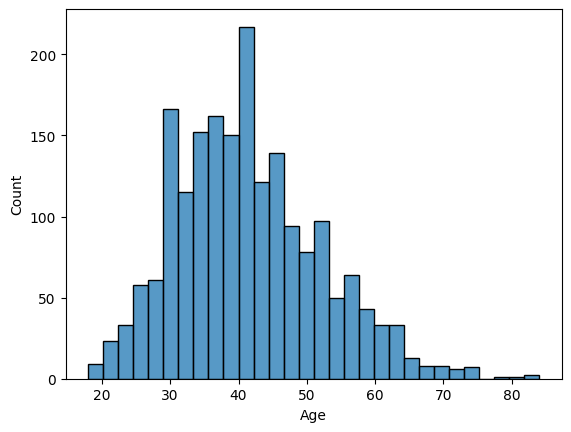

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(x='Age',data=data)
plt.plot()

[]

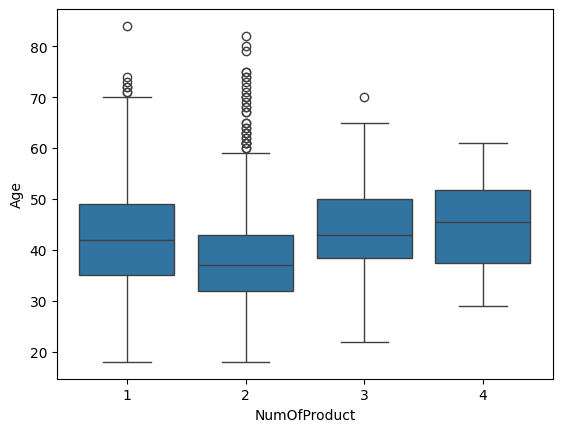

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='NumOfProduct',y='Age',data=data)
plt.plot()

In [ ]:
numeric_data = data.select_dtypes(include='number')
cor_mat = numeric_data.corr()
cor_mat

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProduct,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,1.000000,0.011068,0.014348,-0.008874,-0.012506,-0.004233,-0.048745,0.036312,0.007995,-0.015952
CreditScore,0.011068,1.000000,-0.020358,-0.001111,0.016925,-0.018988,-0.021007,0.043553,-0.020779,-0.032516
Age,0.014348,-0.020358,1.000000,-0.021231,0.015907,-0.050830,-0.020721,0.045966,0.003122,0.360896
Tenure,-0.008874,-0.001111,-0.021231,1.000000,-0.022541,0.052813,0.017779,-0.051487,0.040336,-0.019141
Balance,-0.012506,0.016925,0.015907,-0.022541,1.000000,-0.157890,-0.023834,-0.036355,-0.015688,0.126579
NumOfProduct,-0.004233,-0.018988,-0.050830,0.052813,-0.157890,1.000000,-0.002651,0.041429,0.040548,-0.068749
HasCrCard,-0.048745,-0.021007,-0.020721,0.017779,-0.023834,-0.002651,1.000000,-0.035772,-0.077768,-0.007548
IsActiveMember,0.036312,0.043553,0.045966,-0.051487,-0.036355,0.041429,-0.035772,1.000000,0.009823,-0.213233
EstimatedSalary,0.007995,-0.020779,0.003122,0.040336,-0.015688,0.040548,-0.077768,0.009823,1.000000,0.013108
Exited,-0.015952,-0.032516,0.360896,-0.019141,0.126579,-0.068749,-0.007548,-0.213233,0.013108,1.000000


<Axes: >

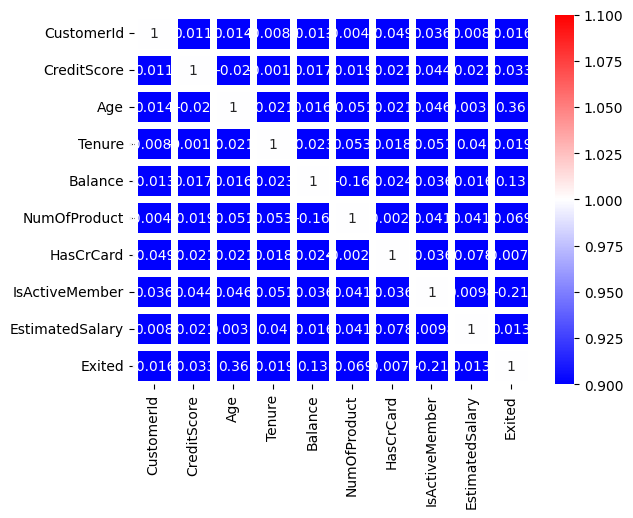

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cor_mat,vmax=1,vmin=1,annot=True,linewidths=5,cmap='bwr')

In [ ]:
data.drop(["CustomerId","Surname"], axis=1, inplace=True)

In [ ]:
data["Gender"] = data["Gender"].map({"Male":1,"Female":0})

In [ ]:
data= pd.get_dummies(data, columns=["Geography"])

In [ ]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProduct,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False
2,645,1,44,8,113755.78,2,1,0,149756.71,1,False,False,True
3,376,0,29,4,115046.74,4,1,0,119346.88,1,False,True,False
4,653,1,58,1,132602.88,1,1,0,5097.67,1,False,True,False


In [ ]:
x=data.drop(['Exited'],axis=1)
y=data['Exited']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
ypred=reg.predict(x_test)

In [ ]:
ypred

array([ 1.05678426,  0.30063633,  0.36826432,  0.26677293,  0.54674267,
        0.47266074,  0.3120807 ,  0.84442017,  0.57302896,  0.63393145,
        0.54794262,  0.463671  ,  0.19837347,  0.46414538,  0.39634958,
        0.2463344 ,  0.70652157,  0.12659524,  0.64615097,  0.79206229,
        1.0599773 ,  0.70382983,  0.44418414,  0.67565805,  0.30812334,
        0.37819134,  0.49784644,  0.68003803,  0.48928359,  0.61896528,
        0.81302944,  0.42542928,  0.82706476,  0.89185082,  0.49829854,
        0.79633045,  0.7789282 ,  0.21612985,  0.56520941,  0.60785275,
        0.51294779,  0.39197375,  0.6117996 ,  0.34556648,  0.30953726,
        0.44122755,  0.36753288,  0.72357987,  0.46108248,  0.76847352,
        0.39660274,  0.84172464,  0.70050023,  0.53378832,  0.74036571,
        0.80117545,  0.45194413,  0.73278627,  0.65824612,  0.17043615,
        0.16593955,  0.7182621 ,  0.04307309,  0.55572616,  0.76134464,
        0.48769247,  0.71503926,  0.34475817,  0.53147195,  0.47

In [ ]:
y_test

,Exited
1610,0
1402,0
1718,0
1054,0
307,1
...,...
1546,0
1073,0
1304,0
334,1


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,ypred)

0.16132400782448852

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(x_train,y_train)

LogisticRegression()

In [ ]:
ypred=classifier.predict(x_test)

In [ ]:
ypred

array([1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,ypred)

In [ ]:
print(cm)

[[143  95]
 [ 78 170]]


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,ypred)

0.6440329218106996

<Axes: >

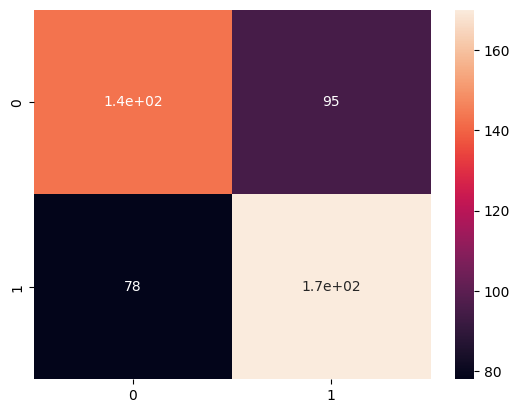

In [ ]:
import seaborn as sns
sns.heatmap(cm,annot=True)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.65      0.60      0.62       238
           1       0.64      0.69      0.66       248

    accuracy                           0.64       486
   macro avg       0.64      0.64      0.64       486
weighted avg       0.64      0.64      0.64       486

